In [3]:
!pip install -q -U transformers datasets peft bitsandbytes trl wandb scikit-learn matplotlib

In [1]:
!pip install --upgrade trl

In [9]:
import torch
import wandb
import os
import random
import numpy as np
from google.colab import userdata

# login to wandb
wandb.login(relogin=True)

# house rules: reproducibility
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)

print("Libraries installed and Seed set")

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nishanttg (nishantg) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Libraries installed and Seed set


### **Loading Raw Data**

In [10]:
import tarfile
import urllib.request
from glob import glob
from tqdm import tqdm
import pandas as pd
from datasets import Dataset

In [16]:
# 1. Download & Extract Stanford Data (If not present)
if not os.path.exists("aclImdb"):
    print("Downloading Raw Stanford Dataset")
    url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
    urllib.request.urlretrieve(url, "aclImdb_v1.tar.gz")
    print("Extracting")
    with tarfile.open("aclImdb_v1.tar.gz", "r:gz") as tar:
        tar.extractall()

In [17]:
# 2. Manual Loader Function (Consistent with Day 1 & 2)
def load_raw_imdb(data_dir='aclImdb'):
    data = {'train': [], 'test': []}
    for split in ['train', 'test']:
        for sentiment, label in [('pos', 1), ('neg', 0)]:
            path = os.path.join(data_dir, split, sentiment, '*.txt')
            files = glob(path)
            # Load subset for speed (or all if you have time).
            # We load all here to ensure fair sampling later.
            for file_path in tqdm(files, desc=f"Loading {split}/{sentiment}", leave=False):
                with open(file_path, 'r', encoding='utf-8') as f:
                    data[split].append({'text': f.read(), 'label': label})

    # Shuffle & Convert to DataFrame
    train_df = pd.DataFrame(data['train']).sample(frac=1, random_state=SEED).reset_index(drop=True)
    test_df = pd.DataFrame(data['test']).sample(frac=1, random_state=SEED).reset_index(drop=True)
    return train_df, test_df


In [18]:
print("Loading Data from Raw Files")
train_df_raw, test_df_raw = load_raw_imdb()

Loading Data from Raw Files


In [19]:
# 3. Format for Chat Fine-Tuning
# SFTTrainer expects a column called "messages" with a list of dictionaries
def format_to_chat(row):
    label_text = "Positive" if row['label'] == 1 else "Negative"
    return [
        {"role": "user", "content": f"Classify the sentiment of this review:\n\n{row['text'][:1000]}"},
        {"role": "assistant", "content": label_text}
    ]

In [20]:
# Apply formatting
print("Formatting data for LLM")
train_df_raw['messages'] = train_df_raw.apply(format_to_chat, axis=1)
test_df_raw['messages'] = test_df_raw.apply(format_to_chat, axis=1)

Formatting data for LLM


In [21]:
# 4. Convert to Hugging Face Dataset Object (Required for Trainer)
# We select a subset (2000 train, 500 eval) to fit "Lightweight Adaptation" budget
train_dataset = Dataset.from_pandas(train_df_raw[['messages']]).select(range(2000))
eval_dataset = Dataset.from_pandas(test_df_raw[['messages']]).select(range(500))

In [22]:
print(f"Data Ready. Training on {len(train_dataset)} samples.")
print(f"Sample Input: {train_dataset[0]['messages']}")

Data Ready. Training on 2000 samples.
Sample Input: [{'content': 'Classify the sentiment of this review:\n\nOlivier, Kosentsev, Richardson, Coranado, Zefferelli, and Almerayeda have all directed Hamlet but Branagh\'s the only one who got it right.<br /><br />This is the only film of "Hamlet" that contains the full four hours of William Shakespeare\'s masterpiece and gives a unique feel to the whole story.<br /><br />Not many directors could pull this off without boring their audience but Branagh\'s skillful use of bravora film style and stunt casting allows people to see the importance of the scenes that are usually cut out.<br /><br />Examples of this include Gerarde Depardue as Ranyaldo whos entire purpose in the film was to simply say "yes my lord" as Polonius asks him to spy on Leartes. This also included Billy Crystal as the grave digger, Robin Williams as Osric, Jack Lemmon as Marcellous, and Charlton Heston as the actor.<br /><br />Branagh\'s performance of the Act 4 scene 4 sol

### **Load Model and LORA Config (Qwen-0.5)**

In [7]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig , get_peft_model

In [11]:
model_id = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype = torch.float16,
    device_map = "auto",
)

`torch_dtype` is deprecated! Use `dtype` instead!


In [12]:
# LoRA Config

peft_config = LoraConfig(
    r=16, # rank
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "v_proj"] # Target Attention Layers
)

model = get_peft_model(model,peft_config)
model.print_trainable_parameters()

trainable params: 1,081,344 || all params: 495,114,112 || trainable%: 0.2184


### **Fine-Tuning**

In [4]:
from trl import SFTTrainer
from transformers import TrainingArguments

In [13]:
run = wandb.init(
    project = "Week-4",
    name = "day3-lora-qwen-0.5b",
    job_type = "fine-tuning",
    config = {
        "model" : 'Qwen/Qwen2.5-0.5B-Instruct',
        "dataset" : 'aclImdb',
        "method" : "LoRA"
    }
)

In [30]:
# 2. Configure Training
# We set report_to="wandb" so the Trainer knows to use our active run
training_args = TrainingArguments(
    output_dir="./qwen-lora-aclImdb",
    num_train_epochs=1,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    logging_steps=25,
    fp16=True,
    save_strategy="no",
    report_to="wandb",  # <--- Tells HF to log to the active W&B run
    run_name="day3-lora-qwen-0.5b" # Matches our init name
)

trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    args=training_args,
)

Tokenizing train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

The model is already on multiple devices. Skipping the move to device specified in `args`.


In [31]:
print("Starting LoRA Training")
trainer.train()
print("Training Complete")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Starting LoRA Training


Step,Training Loss
25,3.190300
50,2.864600
75,2.831800
100,2.833800
125,2.843000


Training Complete


## **Metrics + Calibration + Confusion Matrix**

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import calibration_curve
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report
from tqdm import tqdm
import pandas as pd

In [36]:
y_true = []
y_prob = []

model.eval()

# 1. Inference Loop (Gather Data)
for sample in tqdm(eval_dataset):
    # Extract True Label
    true_label = 1 if sample['messages'][1]['content'] == "Positive" else 0

    # Extract User Prompt
    user_prompt = sample['messages'][0]['content']

    # Prepare Input
    inputs = tokenizer.apply_chat_template([{"role": "user", "content": user_prompt}],
                                          add_generation_prompt=True, return_tensors="pt").to("cuda")

    # Forward Pass
    with torch.no_grad():
        outputs = model(inputs)
        next_token_logits = outputs.logits[0, -1, :]

        # Get probabilities for "Positive" vs "Negative"
        pos_id = tokenizer.encode("Positive")[0]
        neg_id = tokenizer.encode("Negative")[0]

        pos_score = next_token_logits[pos_id].item()
        neg_score = next_token_logits[neg_id].item()

        # Softmax
        prob_pos = np.exp(pos_score) / (np.exp(pos_score) + np.exp(neg_score))

        y_true.append(true_label)
        y_prob.append(prob_pos)

100%|██████████| 500/500 [00:43<00:00, 11.54it/s]


In [37]:
# 2. Convert Probabilities to Hard Predictions (Threshold 0.5)
y_pred = [1 if p >= 0.5 else 0 for p in y_prob]

In [38]:
# 3. Calculate Standard Metrics
macro_f1 = f1_score(y_true, y_pred, average='macro')
acc = accuracy_score(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=["Negative", "Positive"], output_dict=True)

In [39]:
print(f"\n Final Results:")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Accuracy: {acc:.4f}")


 Final Results:
Macro F1: 0.9057
Accuracy: 0.9060


In [40]:
# 4. Log Metrics to W&B
wandb.log({
    "test/macro_f1": macro_f1,
    "test/accuracy": acc,
    "test/precision_pos": report['Positive']['precision'],
    "test/recall_pos": report['Positive']['recall']
})

In [41]:
# 5. Log Confusion Matrix (Native W&B Plot)
wandb.log({
    "confusion_matrix": wandb.plot.confusion_matrix(
        probs=None,
        y_true=y_true,
        preds=y_pred,
        class_names=["Negative", "Positive"]
    )
})

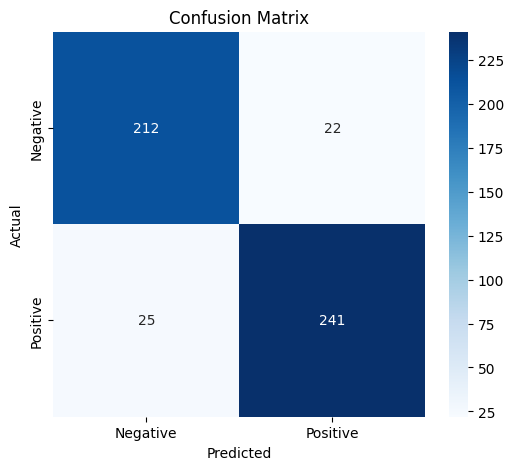

In [43]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

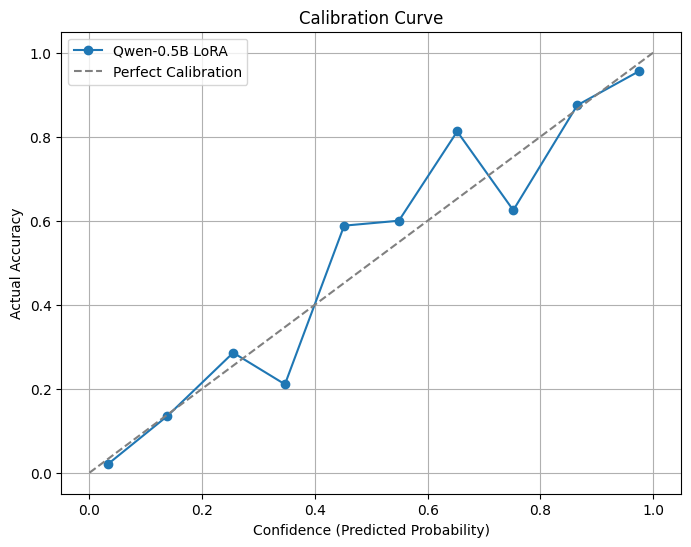

In [42]:
# 6. Plot & Log Calibration Curve (Stretch Booster)
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Qwen-0.5B LoRA')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
plt.xlabel('Confidence (Predicted Probability)')
plt.ylabel('Actual Accuracy')
plt.title('Calibration Curve')
plt.legend()
plt.grid()

# Save plot to W&B
wandb.log({"calibration_curve": wandb.Image(plt)})

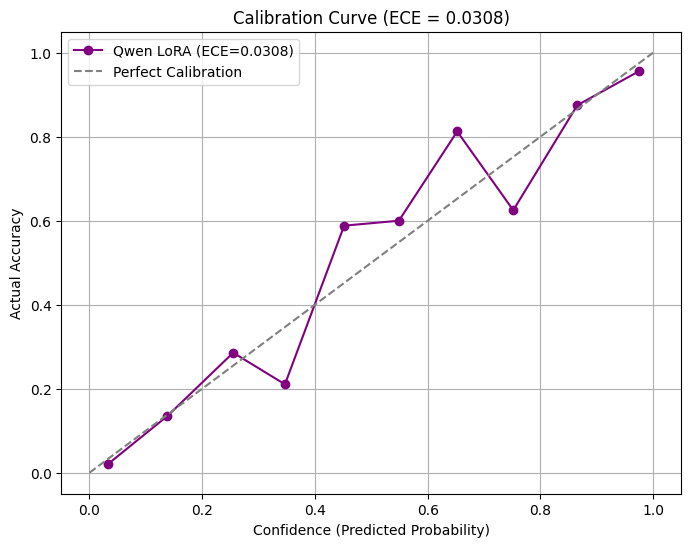

In [44]:
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)

# Calculate ECE (Expected Calibration Error)
# ECE = weighted average of |acc - conf|
weights = np.histogram(y_prob, bins=10, range=(0, 1))[0] / len(y_prob)
ece = np.average(np.abs(prob_true - prob_pred), weights=weights[:len(prob_true)])

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label=f'Qwen LoRA (ECE={ece:.4f})', color='purple')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
plt.xlabel('Confidence (Predicted Probability)')
plt.ylabel('Actual Accuracy')
plt.title(f'Calibration Curve (ECE = {ece:.4f})')
plt.legend()
plt.grid()
plt.show()

In [45]:
wandb.log({
    "calibration_ece": ece,
})

In [46]:
# Finish Run
wandb.finish()
print("Day-3 Complete: Metrics, Confusion Matrix, and Calibration logged")

calibration_ece,▁
test/accuracy,▁
test/macro_f1,▁
test/precision_pos,▁
test/recall_pos,▁
train/entropy,█▃▁▁▁
train/epoch,▁▃▅▆██
train/global_step,▁▃▅▆██████
train/grad_norm,█▃▂▁▁
train/learning_rate,█▆▅▃▁
+3,...


Day-3 Complete: Metrics, Confusion Matrix, and Calibration logged


# **Experiment-2 (Scaling up the Train-Test Data)**

In [47]:
import torch
import wandb
import os
import tarfile
import urllib.request
import pandas as pd
import numpy as np
import random
from glob import glob
from tqdm import tqdm
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments
from peft import LoraConfig, get_peft_model
from trl import SFTTrainer
from sklearn.metrics import f1_score, accuracy_score, classification_report

wandb.login()
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


In [48]:
# INCREASED SIZE: 10,000 Train (40%) | 2,000 Eval (For Training Logs)
TRAIN_SIZE = 10000
EVAL_SIZE = 2000

train_dataset = Dataset.from_pandas(train_df_raw[['messages']]).select(range(TRAIN_SIZE))
eval_dataset = Dataset.from_pandas(test_df_raw[['messages']]).select(range(EVAL_SIZE))

print(f"Training on {len(train_dataset)} samples | Validating on {len(eval_dataset)} samples.")


Training on 10000 samples | Validating on 2000 samples.


In [49]:
# --- 4. MODEL & LORA ---
model_id = "Qwen/Qwen2.5-0.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.float16, device_map="auto")

peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "v_proj"]
)
model = get_peft_model(model, peft_config)

In [51]:
# --- 5. TRAINING (THE BIG RUN) ---
run = wandb.init(
    project="Week-4",
    name=f"day3-lora-big-N{TRAIN_SIZE}",
    config={"train_size": TRAIN_SIZE, "model": model_id}
)

training_args = TrainingArguments(
    output_dir="./qwen-lora-big",
    num_train_epochs=1,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4, # Effective batch = 16
    learning_rate=2e-4,
    logging_steps=50,
    fp16=True,
    save_strategy="no",
    report_to="wandb"
)

trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    args=training_args
)


Tokenizing train dataset:   0%|          | 0/10000 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/10000 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

The model is already on multiple devices. Skipping the move to device specified in `args`.


In [52]:
print(f" Starting Training ")
trainer.train()
print(" Training Complete.")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


 Starting Training 


Step,Training Loss
50,2.995300
100,2.840400
150,2.843600
200,2.824800
250,2.811500
300,2.789900
350,2.806900
400,2.800600
450,2.796300
500,2.773400


 Training Complete.


In [60]:
# --- 1. SETUP CORRECT TOKEN IDS (CRITICAL FIX) ---
# We need to ensure we aren't getting "Start of Sentence" tokens
# We also check for " Positive" (with space) just in case the model adds one
pos_id = tokenizer.encode("Positive", add_special_tokens=False)[0]
neg_id = tokenizer.encode("Negative", add_special_tokens=False)[0]

In [61]:
print(f" DEBUG: Tracking Token IDs -> Positive: {pos_id} | Negative: {neg_id}")

 DEBUG: Tracking Token IDs -> Positive: 35490 | Negative: 38489


In [62]:
print("Re-running Inference to capture Probabilities for ECE")
print(f"Sample size: {len(final_test_dataset)} (using the Final Test Set)")

y_true = []
y_prob = []

model.eval()

Re-running Inference to capture Probabilities for ECE
Sample size: 2500 (using the Final Test Set)


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2ForCausalLM(
      (model): Qwen2Model(
        (embed_tokens): Embedding(151936, 896)
        (layers): ModuleList(
          (0-23): 24 x Qwen2DecoderLayer(
            (self_attn): Qwen2Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=896, out_features=896, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=896, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=896, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): Linear(in_feature

In [63]:
# --- 2. RUN EVALUATION ---
print(f" Running Final Eval on {len(final_test_dataset)} fresh samples")

model.eval()
y_true = []
y_prob = []

for sample in tqdm(final_test_dataset):
    # Truth
    true_label = 1 if sample['messages'][1]['content'] == "Positive" else 0
    user_prompt = sample['messages'][0]['content']

    # Input
    inputs = tokenizer.apply_chat_template([{"role": "user", "content": user_prompt}],
                                          add_generation_prompt=True, return_tensors="pt").to("cuda")

    with torch.no_grad():
        outputs = model(inputs)
        # Get logits for the last generated token
        next_token_logits = outputs.logits[0, -1, :]

        # Extract scores specifically for our target IDs
        pos_score = next_token_logits[pos_id].item()
        neg_score = next_token_logits[neg_id].item()

        # Softmax between ONLY these two candidates
        # This asks: "Given it must be Positive or Negative, what is the prob of Positive?"
        prob_pos = np.exp(pos_score) / (np.exp(pos_score) + np.exp(neg_score))

    y_true.append(true_label)
    y_prob.append(prob_pos)

 Running Final Eval on 2500 fresh samples


100%|██████████| 2500/2500 [02:54<00:00, 14.36it/s]


In [64]:
# --- 3. METRICS ---
# Convert to hard predictions (Threshold 0.5)
y_pred = [1 if p >= 0.5 else 0 for p in y_prob]

f1 = f1_score(y_true, y_pred, average='macro')
acc = accuracy_score(y_true, y_pred)

print(f"\n FINAL RESULT (N={len(final_test_dataset)}):")
print(f"Macro F1: {f1:.4f}")
print(f"Accuracy: {acc:.4f}")

wandb.log({"final_f1": f1, "final_acc": acc})



 FINAL RESULT (N=2500):
Macro F1: 0.9108
Accuracy: 0.9108



Generating Confusion Matrix...


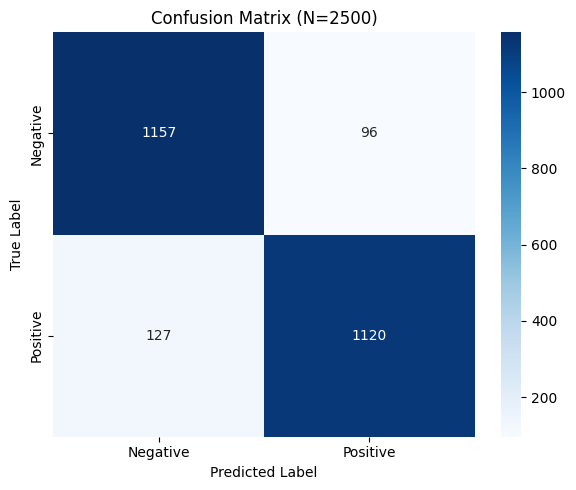

<Figure size 640x480 with 0 Axes>

In [65]:
# --- 4. PLOT CONFUSION MATRIX ---
print("\nGenerating Confusion Matrix...")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix (N={len(y_true)})')
plt.tight_layout()
plt.show()

# Log to W&B
wandb.log({"confusion_matrix_img": wandb.Image(plt)})


In [66]:
# --- 5. PLOT RELIABILITY DIAGRAM (ECE) ---
print("Generating Reliability Diagram...")
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)

Generating Reliability Diagram...


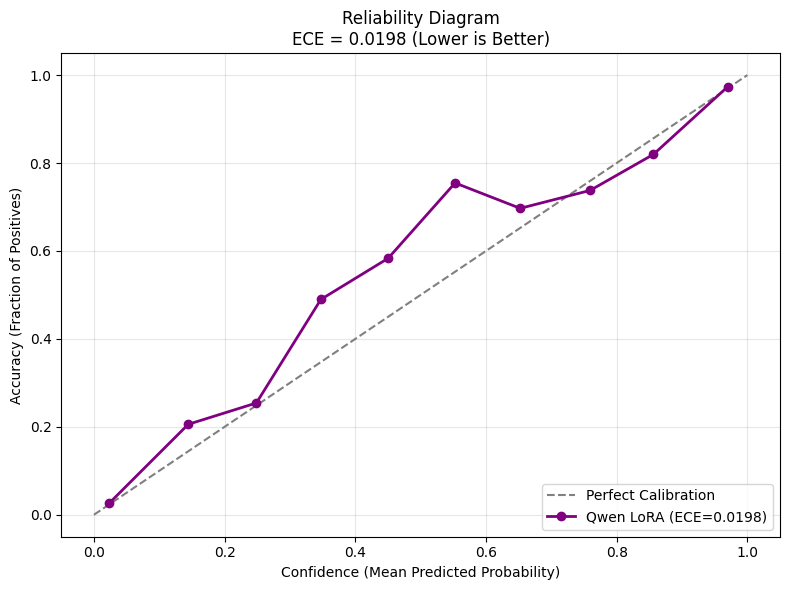

In [67]:
# Calculate ECE
weights = np.histogram(y_prob, bins=10, range=(0, 1))[0] / len(y_prob)
ece = np.average(np.abs(prob_true - prob_pred), weights=weights[:len(prob_true)])

plt.figure(figsize=(8, 6))
# Plot Perfect Calibration
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
# Plot Model
plt.plot(prob_pred, prob_true, marker='o', color='purple', linewidth=2, label=f'Qwen LoRA (ECE={ece:.4f})')

plt.xlabel('Confidence (Mean Predicted Probability)')
plt.ylabel('Accuracy (Fraction of Positives)')
plt.title(f'Reliability Diagram\nECE = {ece:.4f} (Lower is Better)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [68]:
# Log to W&B
wandb.log({
    "reliability_diagram": wandb.Image(plt),
    "ece_score": ece
})

print(f" Analysis Complete. ECE Score: {ece:.4f}")
wandb.finish()

 Analysis Complete. ECE Score: 0.0198


ece_score,▁
final_acc,▁
final_f1,▁
train/entropy,█▃▃▃▂▁▂▂▁▁▂▂▂
train/epoch,▁▂▂▃▃▄▅▅▆▆▇██
train/global_step,▁▂▂▃▃▄▅▅▆▆▇█████
train/grad_norm,█▄▂▂▄▂▁▅▄▂▂▁
train/learning_rate,█▇▇▆▅▅▄▄▃▂▂▁
train/loss,█▃▃▃▂▂▂▂▂▁▂▂
train/mean_token_accuracy,▁▇▆▇▇█▇▇▇████
+1,...


<Figure size 640x480 with 0 Axes>

In [70]:
# saving the plots again cause previously logged after plt.show() which cleared the screen to white canvas.
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.calibration import calibration_curve
from sklearn.metrics import confusion_matrix
import wandb

# --- CONFIGURATION ---
# 1. Paste the ID from your browser URL here
RUN_ID = "003i9nxn"
PROJECT_NAME = "Week-4"

# 2. Resume the run
run = wandb.init(
    project=PROJECT_NAME,
    id=RUN_ID,
    resume="must" # This forces it to use the existing run
)

print(f" Resumed Run {RUN_ID}. Generating plots")

# --- PLOT 1: CONFUSION MATRIX ---
# Create figure explicitly
fig_cm = plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix (N={len(y_true)})')
plt.tight_layout()

# Log figure BEFORE showing
wandb.log({"confusion_matrix_fixed": wandb.Image(fig_cm)})
plt.close(fig_cm) # Close to clean up

#  PLOT 2: RELIABILITY DIAGRAM (ECE)
fig_rel = plt.figure(figsize=(8, 6))

prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)

# Recalculate ECE
weights = np.histogram(y_prob, bins=10, range=(0, 1))[0] / len(y_prob)
ece = np.average(np.abs(prob_true - prob_pred), weights=weights[:len(prob_true)])

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
plt.plot(prob_pred, prob_true, marker='o', color='purple', linewidth=2, label=f'Qwen LoRA (ECE={ece:.4f})')

plt.xlabel('Confidence (Mean Predicted Probability)')
plt.ylabel('Accuracy (Fraction of Positives)')
plt.title(f'Reliability Diagram\nECE = {ece:.4f} (Lower is Better)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Log figure BEFORE showing
wandb.log({
    "reliability_diagram_fixed": wandb.Image(fig_rel),
    "ece_score": ece
})
plt.close(fig_rel)

print("Charts uploaded to the SAME run.")
wandb.finish()

 Resumed Run 003i9nxn. Generating plots
Charts uploaded to the SAME run.


ece_score,▁
ece_score,0.01979
final_acc,0.9108
final_f1,0.91078
total_flos,5810091110866944
train/entropy,2.78992
train/epoch,1
train/global_step,625
train/grad_norm,0.43806
train/learning_rate,1e-05
train/loss,2.7946


In [71]:
import shutil
from google.colab import files

# 1. Define where the model was saved (from your TrainingArguments)
# We used output_dir="./qwen-lora-big" in the big run
source_dir = "./qwen-lora-big"
zip_name = "day3_lora_model"

print(f"Zipping {source_dir}...")

# 2. Create Zip file
shutil.make_archive(zip_name, 'zip', source_dir)

# 3. Download
print(" Downloading zip file")
files.download(f"{zip_name}.zip")

Zipping ./qwen-lora-big...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>